In [43]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
import matplotlib.cm as cm
import matplotlib.colors as colors
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd

In [44]:
def gr_L_new(T_l, H_l_i, E, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    E=(E+1e-6*1j)*np.eye(N)
    T_1 = np.block([
        [np.linalg.inv(T_l) @ (E-H_l_i[1]), -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    T_2 = np.block([
        [np.linalg.inv(T_l) @ (E-H_l_i[0]), -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    Tmat = T_2 @  T_1

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(E- H_l_i[0] - T_l @ S1 @ np.linalg.inv(S2))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l_i, H_r_i, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l_i[0].shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_device = (E + 1j*eta) * I_device

    # 左右自能
    gcl = gr_L_new(T_l, H_l_i, E)
    Sigma_L = zinengr_L(T_LD, gcl)

    gcr = gr_L_new(T_r, H_r_i, E)
    Sigma_R = zinengr_L(T_RD, gcr)

    # 初始化 2*xshumu 的超大网格
    A_DD = [[Z.copy() for _ in range(xshumu*2)] for _ in range(xshumu*2)]

    for i in range(xshumu*2):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == 2*xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < 2*xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD_matrix = np.block(A_DD)
    #G_DD_r = np.linalg.inv(A_DD_matrix)
    #G_RL = G_DD_r[-d_device:, :d_device]

    # ================= 优化：用求解线性方程组代替全矩阵求逆 =================
    N_total = A_DD_matrix.shape[0]

    B = np.zeros((N_total, d_device), dtype=complex)
    B[:d_device, :] = np.eye(d_device, dtype=complex)
    
    X = np.linalg.solve(A_DD_matrix, B)

    G_RL = X[-d_device:, :]


    return G_RL, Sigma_R, Sigma_L

def Gr_DD_2(H_q_list, H_l_i, H_r_i, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    
    # 💥 核心修正 1：总层数现在是 2 * xshumu
    N_total = 2 * xshumu
    
    d_device = H_q_list[0].shape[0]  
    I_device = np.eye(d_device, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ================= 1. 计算左右电极自能 =================
    # 完全采用你刚刚修复好的双层原胞表面格林函数 gr_L_new
    gcl = gr_L_new(T_l, H_l_i, E)
    Sigma_L = zinengr_L(T_LD, gcl)

    gcr = gr_L_new(T_r, H_r_i, E)
    Sigma_R = zinengr_L(T_RD, gcr)

    # 跃迁矩阵
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N_total, d_device, d_device), dtype=complex)
    
    # ================= 2. 递推扫描 (Dyson Equation) =================
    # 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 中间层：把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N_total - 1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 最后一层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N_total-2] @ V
    gL[N_total-1] = np.linalg.inv(EI_device - H_q_list[N_total-1] - Sigma_eff_L_last - Sigma_R)
    
    # ================= 3. 回溯提取透射矩阵 G_RL =================
    # (即 G_{N_total-1, 0}，波函数从左侧 0 传播到右侧 N_total-1)
    G_RL = gL[N_total-1].copy()
    for n in range(N_total-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品
    return G_RL, Sigma_R, Sigma_L
  
def calc_G_total_at_E_1(E_val, matrix_dict, xshumu, eta):
    """
    计算给定单一能量点 E_val 下，所有 transverse modes 的总电导。
    纯 2x2 版本！直接传入 2*xshumu 层的列表！
    """
    G_total_at_E = 0.0  
    
    # 遍历字典中所有的横向模式
    for dhs, mats in matrix_dict.items():
        
        # 1. 直接从字典提取 2x2 的数据
        H_q_list = mats["H_q_list"]  # 长度已经是 2 * xshumu 了
        T_21 = mats["T_21"]          
        
        H_l_i = mats["H_l_i"]        # 包含 2 个元素的左电极列表
        T_l = mats["T_l"]
        
        # 注意：这里要对应你在字典里的名字 "H_r_2"（你在前面存成了 "H_r_2": H_r_i）
        H_r_i = mats["H_r_2"]        # 包含 2 个元素的右电极列表
        T_r = mats["T_r"]
        
        T_LD = mats["T_LD"]
        T_RD = mats["T_RD"]

        # 2. 直接调用你原来那个修复后的 Gr_DD
        G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l_i, H_r_i, 
                                       T_21, T_LD, T_l, T_RD, T_r, 
                                       xshumu, E_val, eta)
        
        # 3. 计算透射率
        zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
        zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
        G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
        G_total_at_E += np.real(G_complex)
        
    return G_total_at_E


In [45]:
def build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, a, xshumu):
    """
    根据锯齿形纳米管的结构参数，构建所有波矢 ky 通道下的哈密顿量与跃迁矩阵字典。
    """
    max_duihaoshu = m
    matrix_dict = {}

    for duihaoshu in range(1, max_duihaoshu + 1):  
        # 计算当前通道的 ky
        ky = np.pi * (duihaoshu + 0.5) / (a * m)
        
        # --- 中心散射区 (Quantum Dot/Scattering Region) ---
        H_q_1 = H_onstie_1(mu_q, t, a, ky)
        H_q_2 = H_onstie_2(mu_q, t, a, ky)
        T_21 = H_hop(t)

        # 交替添加 H_q_1 和 H_q_2，总长度为 xshumu*2(实际是xshum元胞，只是1元胞有两陈)
        H_q_list = []
        for i in range(xshumu*2):
            if i % 2 == 0:
                H_q_list.append(H_q_1)
            else:
                H_q_list.append(H_q_2)
        
        # --- 左侧导线 (Left Lead) ---
        H_l_i=[]
        H_l_1 = H_onstie_1(mu_l, t, a, ky)
        H_l_2 = H_onstie_2(mu_l, t, a, ky)
        H_l_i.append(H_l_2)
        H_l_i.append(H_l_1)

        T_l = H_hop(t).conj().T 
        
        # --- 右侧导线 (Right Lead) ---
        H_r_i=[]
        H_r_1 = H_onstie_1(mu_r, t, a, ky)
        H_r_2 = H_onstie_2(mu_r, t, a, ky)
        H_r_i.append(H_r_1)
        H_r_i.append(H_r_2)
        T_r = H_hop(t)

        # --- 导线与中心区的耦合 ---
        T_LD = H_hop(t) 
        T_RD = H_hop(t).conj().T 

        # 打包存入字典
        matrix_dict[duihaoshu] = {
            "H_q_list": H_q_list,      # 长度为 xshumu 的列表: [H_q_1, H_q_2, H_q_1...]
            "T_21": T_21,
            "H_l_i": H_l_i,            # 存入具体的左右电极分量子晶格
            "T_l": T_l,
            "H_r_2": H_r_i,
            "T_r": T_r,
            "T_LD": T_LD,
            "T_RD": T_RD
        }
        
    return matrix_dict

In [59]:
#中间矩阵信息  形纳米管ky量子化，周长2b*m
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onstie_1(u, t, a ,ky):
    return (t*sx+ u*s0)

def H_onstie_2(u, t, a ,ky):
    return (t*np.exp(1j*ky*a)*np.array([[0, 1], [0, 0]], complex)
    +t*np.exp(-1j*ky*a)*np.array([[0, 0], [1, 0]], complex)
    + u*s0)

def H_hop(t):
    return (t*s0)

mu_q=0
mu_r=-0.1
mu_l=-0.1
t=1

m=1000
a=3
max_duihaoshu= m

xshumu=10 #变下
b=3**0.5

matrix_dict = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t,a, xshumu)




C:\Users\taoji\AppData\Local\Temp\ipykernel_20592\1736507544.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
Calculating Supercell Bands: 100%|██████████| 100/100 [00:00<00:00, 155.02it/s]


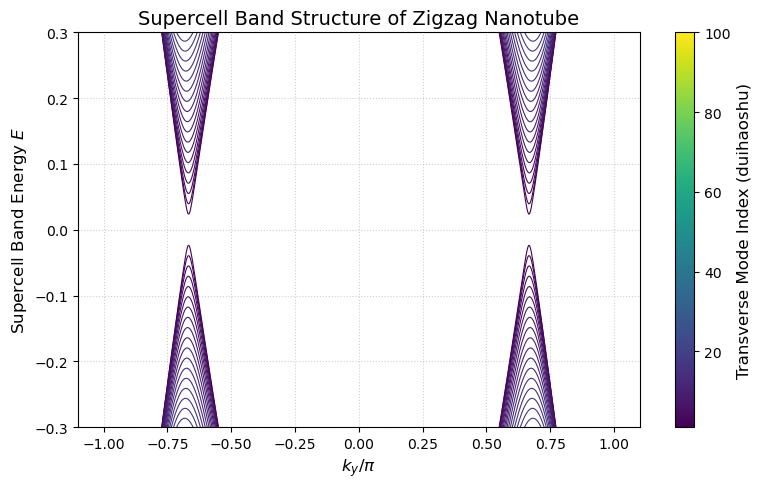

In [55]:
#中间能带
ks1 = np.linspace(-1 * np.pi, 1 * np.pi, 605)
extra_points = np.array([-2 / (3 * np.pi), 2 / (3 * np.pi)])
ks1 = np.sort(np.concatenate((ks1, extra_points)))

# 定义动量空间的布洛赫哈密顿量
def Hk(k, H, T):
    # 注意：这里的 H 和 T 接下来都会是 4x4 的矩阵
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5))

# ================= 2. 设置色图 =================
cmap = cm.get_cmap('viridis')
# 假设 max_duihaoshu = m，根据你前面的设定，比如 m = 3
norm = colors.Normalize(vmin=1, vmax=max_duihaoshu)

# ================= 3. 遍历计算能带 =================
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Supercell Bands"):
    
    # 提取交替的格点在位矩阵和基础跃迁矩阵
    H_q_1 = mats["H_q_list"][0]  # 第1个格点 (2x2)
    H_q_2 = mats["H_q_list"][1]  # 第2个格点 (2x2)
    T_21 = mats["T_21"]          # 基础跃迁 (2x2)
    
    # 💥 核心修改 1：构造 4x4 的超胞在位哈密顿量 H_super
    H_super = np.block([
        [H_q_1,         T_21],
        [T_21.conj().T, H_q_2]
    ])

    # 💥 核心修改 2：构造 4x4 的超胞间跃迁矩阵 T_super (T_21 放在左下角)
    zero_2 = np.zeros((2, 2), dtype=complex)
    T_super = np.block([
       [zero_2, zero_2],
       [T_21,   zero_2]
    ])
 
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:
        # 把 4x4 的超胞矩阵喂给 Hk
        H_k = Hk(k, H_super, T_super)
        # 用 eigvalsh 算厄米矩阵本征值，直接返回实数
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前模式的能带 (现在每个 k 点会解出 4 条能带！)
    for i in range(energies1.shape[1]):
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 4. 设置坐标轴和出图 =================
plt.xlabel(r'$k_y/\pi$', fontsize=12)
plt.ylabel('Supercell Band Energy $E$', fontsize=12)
plt.title('Supercell Band Structure of Zigzag Nanotube', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Transverse Mode Index (duihaoshu)', fontsize=12)
plt.ylim(-0.3,0.3)
plt.tight_layout()
plt.show()

开始并行计算，总共 1000 个能量点，启动 14 个线程...


Calculating Total Conductance: 100%|██████████| 1000/1000 [00:01<00:00, 904.81it/s]


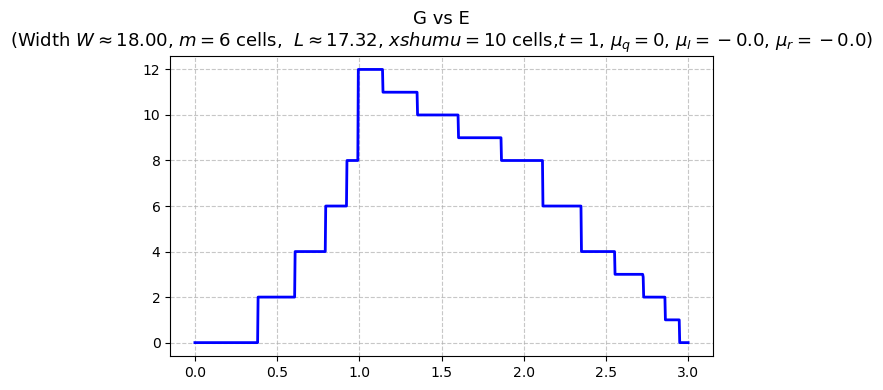

In [53]:
# G vs E xshumu定

E_vals_11 = np.linspace(0, 3, 1000)
eta = 1e-6

print(f"开始并行计算，总共 {len(E_vals_11)} 个能量点，启动 14 个线程...")

# 核心：使用 joblib 开启 14 个进程进行并行计算
# tqdm 用于在主进程中显示分配进度
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E_1)(E_val, matrix_dict, xshumu, eta) 
    for E_val in tqdm(E_vals_11, desc="Calculating Total Conductance")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list_11 = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(6, 4))

plt.plot(E_vals_11, G_total_list_11 , color='b', linewidth=2)

W_val = m * a
L_val= xshumu* b
plt.title('G vs E'+ '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.ylim(0,1)

plt.show()

设定能量 E = 0，准备计算不同长度的标度电导...
xshumu 点数：50 个，启动 10 个线程...


Calculating Length Scaling: 100%|██████████| 50/50 [00:20<00:00,  2.50it/s]


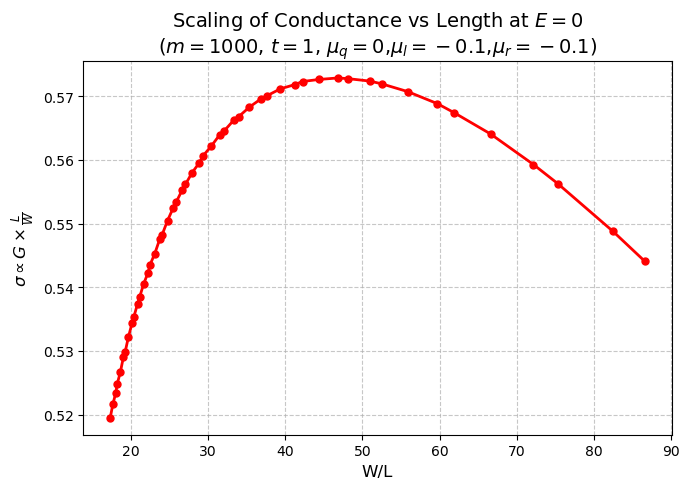

In [60]:
# G vs xshumu
E_fixed = 0 # 【需修改】选择你要观察的固定能量点
eta = 1e-6

# 生成 20 到 100 之间的整数 xshumu，取 50 个点
# 使用 np.unique 保证取整数后剔除重复的值，最终大概会有 ~40 个独一无二的点
xshumu_vals = np.unique(np.linspace(20, 100, 50).astype(int))

print(f"设定能量 E = {E_fixed}，准备计算不同长度的标度电导...")
print(f"xshumu 点数：{len(xshumu_vals)} 个，启动 10 个线程...")

# ================= 2. 定义单线程工作函数 =================
def compute_scaled_G_for_length(xsh_val, E_val, m, b, mu_q, mu_l, mu_r, t, a, eta):
    """
    单个线程的工作内容：
    1. 针对当前的 xshumu 重新构建对应长度的矩阵字典
    2. 计算总电导 G
    3. 返回 G 和 标度电导 G * L / W
    """
    # 1. 重新打包当前长度的字典
    local_dict = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, a, xsh_val)
    
    # 2. 计算当前长度下的电导 G
    G_val = calc_G_total_at_E_1(E_val, local_dict, xsh_val, eta)
    
    # 3. 计算纵坐标：G * xshumu * b / (m * a)
    W = m * a
    L = xsh_val * b
    scaled_G = G_val * L / W
    
    return xsh_val, G_val, scaled_G

# ================= 3. 开启 10 线程并行计算 =================
# 使用 n_jobs=10，将所有参数喂给单线程函数
results = Parallel(n_jobs=10)(
    delayed(compute_scaled_G_for_length)(
        xsh, E_fixed, m, b, mu_q, mu_l, mu_r, t, a, eta
    ) 
    for xsh in tqdm(xshumu_vals, desc="Calculating Length Scaling")
)

# 拆包结果
results = np.array(results)
xshumu_array = results[:, 0]
G_array = results[:, 1]
scaled_G_array = results[:, 2]

# ================= 4. 画出物理图像 =================
plt.figure(figsize=(7, 5))

# 画 xshumu vs (G * L / W)
plt.plot(m*a/(b*xshumu_array), scaled_G_array, marker='o', markersize=5, color='r', linewidth=2, linestyle='-')

# 设置图表信息
plt.title(f'Scaling of Conductance vs Length at $E = {E_fixed}$\n' + 
          rf'($m={m}$, $t={t}$, $\mu_q={mu_q}$,$\mu_l={mu_l}$,$\mu_r={mu_r}$)', fontsize=14)
plt.xlabel(r'W/L', fontsize=12)
plt.ylabel(r'$\sigma \propto G \times \frac{L}{W}$', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [62]:
np.pi/4

0.7853981633974483